# Fractal Number Robustness Experiment / Эксперимент устойчивости фрактальных чисел

**RU.** Этот notebook исследует граничные условия передачи фрактального числа как импульсно-амплитудного сигнала. В предыдущих notebook мы показали, как число кодируется в ячейки алфавита `(P_i, S_i)` и как суммарный сигнал `A(t)` декодируется обратно. Здесь задаем инженерный вопрос: при каких искажениях эта передача остается корректной, а где начинаются ограничения системы.

Мы рассматриваем пять факторов:

1. **Amplitude noise / амплитудная погрешность:** насколько шум может искажать уровни `0`, `1`, `2`, ... до ошибки threshold-декодирования.
2. **Random sample loss / случайная потеря отсчетов:** какая доля отдельных ticks может отсутствовать.
3. **Burst loss / пакетная потеря:** что происходит, если выпадает непрерывный фрагмент сигнала.
4. **Tick-grid jitter / дрожание тактовой сетки:** насколько опасна рассинхронизация дискретных ticks.
5. **Observation length / длина наблюдения:** сколько ticks нужно, чтобы decoder успел увидеть информативные активные участки каждого канала.

Важно: это не утверждение о готовом физическом канале. Это исследовательский слой поверх текущего prototype decoder. Он помогает сформулировать требования к железу и протоколу: стабильный tick grid, достаточный payload window, контролируемый amplitude noise и стратегия против потери данных.

**EN.** This notebook studies boundary conditions for transmitting a fractal number as a pulse-amplitude signal. Previous notebooks showed how a number is encoded into alphabet cells `(P_i, S_i)` and how the summed signal `A(t)` is decoded back. Here we ask the engineering question: under which distortions does transmission remain correct, and where do system limits begin.

We study five factors:

1. **Amplitude noise:** how much noise can perturb levels `0`, `1`, `2`, ... before threshold decoding fails.
2. **Random sample loss:** what fraction of individual ticks may be missing.
3. **Burst loss:** what happens if a continuous signal fragment disappears.
4. **Tick-grid jitter:** how dangerous discrete tick misalignment is.
5. **Observation length:** how many ticks are needed before the decoder sees informative active sections of every channel.

Important: this is not a claim about a finished physical channel. It is a research layer around the current prototype decoder. It helps formulate hardware and protocol requirements: stable tick grid, sufficient payload window, controlled amplitude noise, and a strategy for missing data.

In [1]:
from pathlib import Path
import random
import sys

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "experiments" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from snn_framework import MatrixFractalNumber

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 160)

SEED = 20260606
random.seed(SEED)


def required_payload_ticks(cells) -> int:
    return max(cell.shift_ticks + 3 * cell.period_ticks for cell in cells) + 1


def total_signal(model: MatrixFractalNumber, value: int, digit_count: int, ticks: int) -> list[float]:
    return [sample.total_amplitude for sample in model.signal(value, digit_count=digit_count, ticks=ticks)]


def channel_signals(model: MatrixFractalNumber, value: int, digit_count: int, ticks: int) -> list[list[float]]:
    samples = model.signal(value, digit_count=digit_count, ticks=ticks)
    return [
        [sample.channel_amplitudes[channel] for sample in samples]
        for channel in range(digit_count)
    ]


def decode_ok(model: MatrixFractalNumber, observed, value: int, digit_count: int) -> bool:
    try:
        result = model.decode_step_signal(observed, digit_count=digit_count)
    except ValueError:
        return False
    return result.number == value


def noisy_signal(signal: list[float], sigma: float, rng: random.Random) -> list[float]:
    return [max(0.0, value + rng.gauss(0.0, sigma)) for value in signal]


def dropout_signal(signal: list[float], drop_probability: float, rng: random.Random) -> list[float | None]:
    return [None if rng.random() < drop_probability else value for value in signal]


def burst_loss_signal(signal: list[float], burst_length: int, rng: random.Random) -> list[float | None]:
    if burst_length <= 0:
        return list(signal)
    if burst_length >= len(signal):
        return [None for _ in signal]
    start = rng.randrange(0, len(signal) - burst_length + 1)
    return [None if start <= tick < start + burst_length else value for tick, value in enumerate(signal)]


def jitter_signal(signal: list[float], jitter_probability: float, rng: random.Random) -> list[float]:
    shifted = []
    last_index = len(signal) - 1
    for tick in range(len(signal)):
        if rng.random() < jitter_probability:
            source_tick = min(last_index, max(0, tick + rng.choice([-1, 1])))
        else:
            source_tick = tick
        shifted.append(signal[source_tick])
    return shifted


def monte_carlo_rows(model, value, digit_count, clean_signal, factor_name, levels, corrupt_fn, trials=120):
    rows = []
    for level in levels:
        success = 0
        for trial in range(trials):
            rng = random.Random(SEED + hash((factor_name, str(level), trial)) % 10_000_000)
            observed = corrupt_fn(clean_signal, level, rng)
            success += int(decode_ok(model, observed, value, digit_count))
        rows.append({
            "factor": factor_name,
            "level": level,
            "trials": trials,
            "successes": success,
            "success_rate": success / trials,
        })
    return rows


def plot_success_curve(df: pd.DataFrame, title: str, xlabel: str):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(df["level"], df["success_rate"], marker="o", linewidth=2.2)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("decode success rate")
    ax.set_ylim(-0.05, 1.05)
    return fig, ax

## 1. Baseline Signal And Decoder Assumptions / Базовый сигнал и предположения декодера

**RU.** Используем тот же демонстрационный payload `348`, чтобы связать этот эксперимент с предыдущими notebook. Число кодируется двумя channels: `V_0=8 -> (P=4, S=3)` и `V_1=17 -> (P=9, S=2)`. Decoder получает суммарную амплитуду `A(t)` и восстанавливает channels residual-peeling алгоритмом.

Для текущего prototype важны три предположения:

- decoder знает `digit_count`, то есть сколько channels нужно восстановить;
- receiver имеет общий дискретный tick grid с encoder;
- единичная амплитуда канала равна `1.0`, а threshold равен `0.5`.

**EN.** We use the same demo payload `348` to connect this experiment with previous notebooks. The number is encoded by two channels: `V_0=8 -> (P=4, S=3)` and `V_1=17 -> (P=9, S=2)`. The decoder receives the summed amplitude `A(t)` and reconstructs channels using residual peeling.

For the current prototype, three assumptions matter:

- the decoder knows `digit_count`, meaning how many channels must be recovered;
- the receiver shares the discrete tick grid with the encoder;
- single-channel amplitude is `1.0`, and the threshold is `0.5`.

In [2]:
model = MatrixFractalNumber.article_348_alphabet()
value = 348
digit_count = 2
cells = model.encode_cells(value, digit_count=digit_count)
payload_ticks = required_payload_ticks(cells)
ticks = payload_ticks
samples = model.signal(value, digit_count=digit_count, ticks=ticks)
clean_total = [sample.total_amplitude for sample in samples]
clean_channels = channel_signals(model, value, digit_count, ticks)
clean_result = model.decode_step_signal(clean_total, digit_count=digit_count)

baseline_df = pd.DataFrame([
    {
        "channel_i": cell.digit_index,
        "digit_V_i": cell.digit_value,
        "P_i": cell.period_ticks,
        "S_i": cell.shift_ticks,
        "active_width": cell.active_width_ticks,
        "candidate_cells": len(model.candidate_cells(cell.digit_index)),
        "first_active_ticks": MatrixFractalNumber.cell_active_ticks(cell, ticks=ticks)[:8],
    }
    for cell in cells
])

summary_df = pd.DataFrame([
    {"metric": "value", "value": value, "meaning": "source decimal payload / исходное десятичное число"},
    {"metric": "digit_count", "value": digit_count, "meaning": "known receiver-side channel count / известное приемнику число каналов"},
    {"metric": "payload_ticks", "value": payload_ticks, "meaning": "window used for robustness sweeps / окно наблюдения"},
    {"metric": "decoded value", "value": clean_result.number, "meaning": "clean roundtrip result / результат без искажений"},
    {"metric": "decoded digits", "value": clean_result.digits, "meaning": "recovered mixed-radix digits / восстановленные digits"},
])

baseline_df, summary_df

(   channel_i  digit_V_i  P_i  S_i  active_width  candidate_cells  \
 0          0          8    4    3             2               20   
 1          1         17    9    2             4               34   
 
               first_active_ticks  
 0  [5, 6, 9, 10, 13, 14, 17, 18]  
 1   [6, 7, 8, 9, 10, 15, 16, 17]  ,
            metric    value  \
 0           value      348   
 1     digit_count        2   
 2   payload_ticks       30   
 3   decoded value      348   
 4  decoded digits  (8, 17)   
 
                                                                  meaning  
 0                     source decimal payload / исходное десятичное число  
 1  known receiver-side channel count / известное приемнику число каналов  
 2                    window used for robustness sweeps / окно наблюдения  
 3                       clean roundtrip result / результат без искажений  
 4                  recovered mixed-radix digits / восстановленные digits  )

**Table Fields / Поля таблиц**

**RU.** `channel_i` - индекс канала. `digit_V_i` - mixed-radix digit. `P_i` и `S_i` - период и задержка выбранной ячейки. `active_width` - длительность активной части периода. `candidate_cells` - число допустимых ячеек, среди которых decoder выбирает совпадение. `first_active_ticks` - первые ticks, где данный канал активен. `payload_ticks` - длина окна наблюдения, выбранная так, чтобы каждый channel дал несколько информативных периодов.

**EN.** `channel_i` is the channel index. `digit_V_i` is the mixed-radix digit. `P_i` and `S_i` are period and start delay of the selected cell. `active_width` is active phase width. `candidate_cells` is the number of legal cells considered by the decoder. `first_active_ticks` are the first ticks where this channel is active. `payload_ticks` is the observation window length chosen so each channel contributes several informative periods.

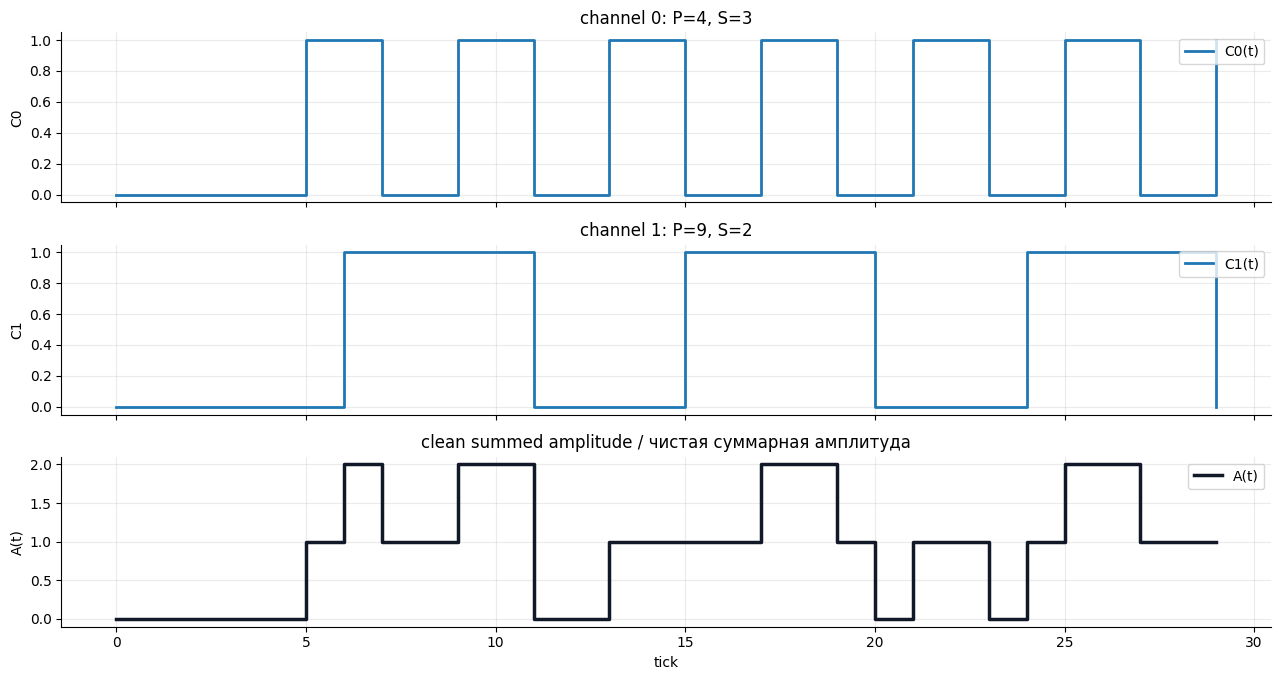

In [3]:
tick_axis = list(range(ticks))
fig, axes = plt.subplots(digit_count + 1, 1, figsize=(13, 2.3 * (digit_count + 1)), sharex=True)
for channel in range(digit_count):
    axes[channel].step(tick_axis, clean_channels[channel], where="post", linewidth=2, label=f"C{channel}(t)")
    axes[channel].set_ylabel(f"C{channel}")
    axes[channel].set_title(f"channel {channel}: P={cells[channel].period_ticks}, S={cells[channel].shift_ticks}")
    axes[channel].legend(loc="upper right")
axes[-1].step(tick_axis, clean_total, where="post", color="#111827", linewidth=2.5, label="A(t)")
axes[-1].set_title("clean summed amplitude / чистая суммарная амплитуда")
axes[-1].set_ylabel("A(t)")
axes[-1].set_xlabel("tick")
axes[-1].legend(loc="upper right")
fig.tight_layout()

## 2. Amplitude Noise Budget / Бюджет амплитудной ошибки

**RU.** В текущей модели один активный канал добавляет амплитуду `1.0`, а decoder использует threshold `0.5`. Поэтому идеальное бинарное различение имеет симметричный запас `0.5`: активный уровень `1` может просесть почти на `0.5`, а неактивный уровень `0` может подняться почти до `0.5`. Для суммарного сигнала уровни `0`, `1`, `2`, ... должны оставаться различимыми после residual subtraction.

В физической системе это означает требование к SNR, quantization и drift: noise не должен часто переводить активные участки ниже threshold или создавать ложные активные участки, которые будут мешать residual peeling.

**EN.** In the current model, one active channel contributes amplitude `1.0`, and the decoder uses threshold `0.5`. Therefore ideal binary discrimination has a symmetric margin of `0.5`: active level `1` may drop by almost `0.5`, while inactive level `0` may rise almost to `0.5`. For the summed signal, levels `0`, `1`, `2`, ... must remain distinguishable after residual subtraction.

For a physical system this becomes an SNR, quantization, and drift requirement: noise must not frequently push active sections below threshold or create false active sections that interfere with residual peeling.

,level,expected_state,decision_rule,max_safe_error,system_requirement
0,0,inactive,value < 0.5,+0.5 before false active,"baseline, offset and positive noise should stay below threshold"
1,1,one active channel,value >= 0.5,-0.5 before missed active,negative noise and attenuation should not cross threshold
2,2,two active channels,residual peeling should see two unit contributions,depends on subtraction order,multi-level amplitude must remain decomposable into unit steps


,factor,level,trials,successes,success_rate
0,gaussian amplitude noise sigma,0.00,120,120,1.000000
1,gaussian amplitude noise sigma,0.05,120,120,1.000000
2,gaussian amplitude noise sigma,0.10,120,120,1.000000
3,gaussian amplitude noise sigma,0.15,120,119,0.991667
4,gaussian amplitude noise sigma,0.20,120,117,0.975000
5,gaussian amplitude noise sigma,0.25,120,102,0.850000
6,gaussian amplitude noise sigma,0.30,120,94,0.783333
7,gaussian amplitude noise sigma,0.35,120,72,0.600000
8,gaussian amplitude noise sigma,0.40,120,55,0.458333
9,gaussian amplitude noise sigma,0.50,120,42,0.350000


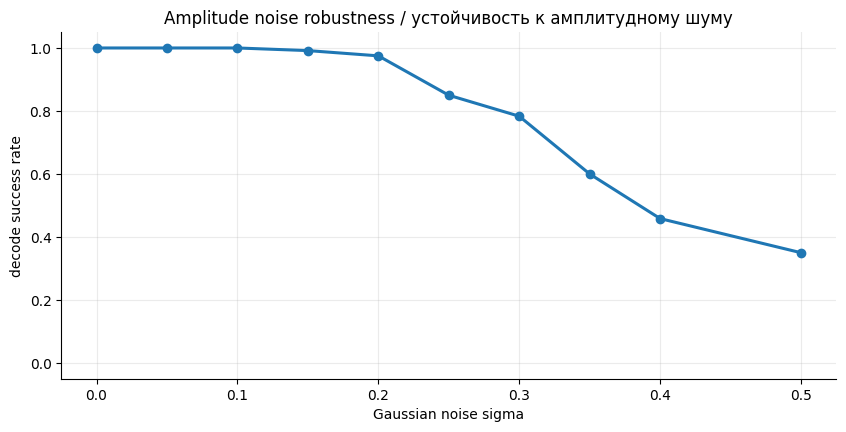

In [4]:
threshold = 0.5
noise_budget_df = pd.DataFrame([
    {
        "level": 0,
        "expected_state": "inactive",
        "decision_rule": "value < 0.5",
        "max_safe_error": "+0.5 before false active",
        "system_requirement": "baseline, offset and positive noise should stay below threshold",
    },
    {
        "level": 1,
        "expected_state": "one active channel",
        "decision_rule": "value >= 0.5",
        "max_safe_error": "-0.5 before missed active",
        "system_requirement": "negative noise and attenuation should not cross threshold",
    },
    {
        "level": 2,
        "expected_state": "two active channels",
        "decision_rule": "residual peeling should see two unit contributions",
        "max_safe_error": "depends on subtraction order",
        "system_requirement": "multi-level amplitude must remain decomposable into unit steps",
    },
])

noise_levels = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
noise_df = pd.DataFrame(monte_carlo_rows(
    model,
    value,
    digit_count,
    clean_total,
    "gaussian amplitude noise sigma",
    noise_levels,
    lambda signal, level, rng: noisy_signal(signal, level, rng),
))

display(noise_budget_df)
display(noise_df)
plot_success_curve(noise_df, "Amplitude noise robustness / устойчивость к амплитудному шуму", "Gaussian noise sigma")
plt.show()

## 3. Random Sample Loss / Случайная потеря отсчетов

**RU.** `None` означает, что receiver не получил отсчет на данном tick. Текущий decoder пропускает такие точки при matching. Поэтому случайная потеря части samples может быть допустима, если оставшиеся ticks всё еще покрывают активные окна каждого candidate channel.

Практический вывод заранее: важна не только доля потерянных samples, но и то, какие именно ticks потеряны. Если потеря равномерная, decoder часто сохраняет достаточно evidence. Если исчезли ключевые active windows старшего канала, восстановление становится ненадежным.

**EN.** `None` means the receiver did not observe a sample at that tick. The current decoder skips such points during matching. Therefore random loss of some samples may be tolerated if remaining ticks still cover active windows of each candidate channel.

The practical lesson: the loss rate is not the only thing that matters. Which ticks are missing also matters. Uniformly scattered loss often leaves enough evidence, while losing key active windows of a higher channel makes recovery unreliable.

,factor,level,trials,successes,success_rate
0,random sample loss probability,0.00,120,120,1.000000
1,random sample loss probability,0.05,120,117,0.975000
2,random sample loss probability,0.10,120,113,0.941667
3,random sample loss probability,0.20,120,100,0.833333
4,random sample loss probability,0.30,120,75,0.625000
5,random sample loss probability,0.40,120,63,0.525000
6,random sample loss probability,0.50,120,50,0.416667
7,random sample loss probability,0.60,120,31,0.258333
8,random sample loss probability,0.70,120,13,0.108333


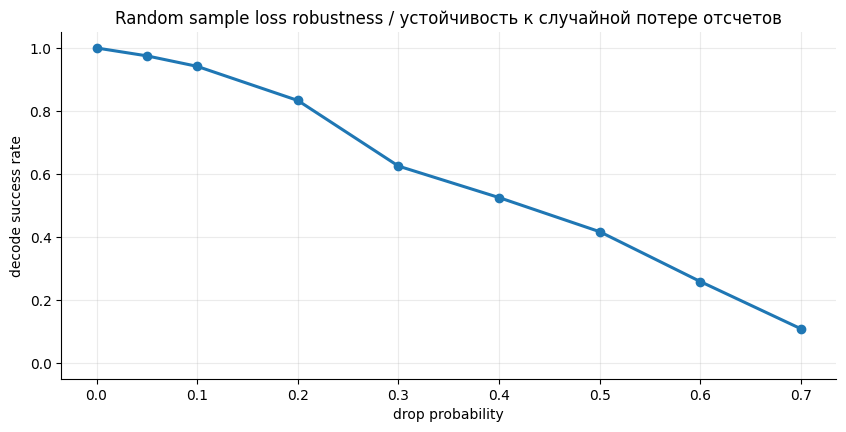

In [5]:
drop_levels = [0.00, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
dropout_df = pd.DataFrame(monte_carlo_rows(
    model,
    value,
    digit_count,
    clean_total,
    "random sample loss probability",
    drop_levels,
    lambda signal, level, rng: dropout_signal(signal, level, rng),
))

display(dropout_df)
plot_success_curve(dropout_df, "Random sample loss robustness / устойчивость к случайной потере отсчетов", "drop probability")
plt.show()

## 4. Burst Loss / Непрерывная потеря фрагмента

**RU.** Burst loss моделирует ситуацию, когда канал передачи или sensor временно “слепнет”: пропадает не случайный набор точек, а непрерывный интервал. Для периодических генераторов это опаснее, потому что burst может закрыть весь информативный active segment одного из channels.

**EN.** Burst loss models a temporary blind interval in the channel or sensor: not a random set of points disappears, but a continuous interval. For periodic generators this is more dangerous because a burst may cover an entire informative active segment of one channel.

,factor,level,trials,successes,success_rate
0,contiguous burst loss length,0,120,120,1.000000
1,contiguous burst loss length,1,120,114,0.950000
2,contiguous burst loss length,2,120,108,0.900000
3,contiguous burst loss length,3,120,108,0.900000
4,contiguous burst loss length,4,120,98,0.816667
5,contiguous burst loss length,6,120,93,0.775000
6,contiguous burst loss length,8,120,80,0.666667
7,contiguous burst loss length,10,120,48,0.400000
8,contiguous burst loss length,12,120,42,0.350000
9,contiguous burst loss length,16,120,34,0.283333


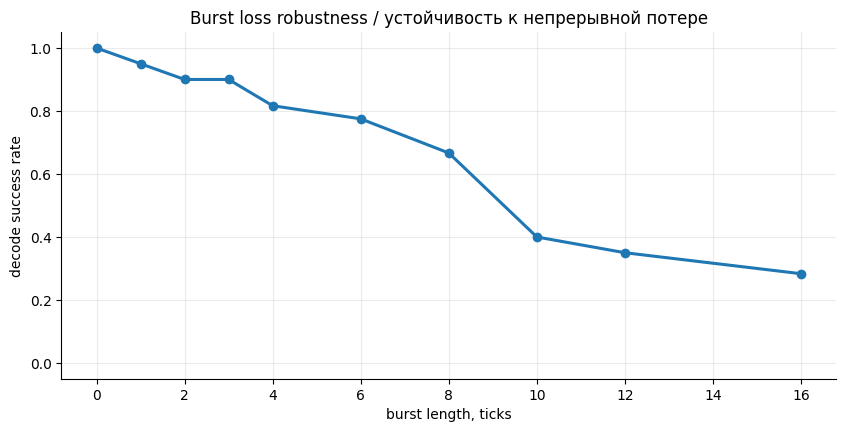

In [6]:
burst_lengths = [0, 1, 2, 3, 4, 6, 8, 10, 12, 16]
burst_df = pd.DataFrame(monte_carlo_rows(
    model,
    value,
    digit_count,
    clean_total,
    "contiguous burst loss length",
    burst_lengths,
    lambda signal, level, rng: burst_loss_signal(signal, int(level), rng),
))

display(burst_df)
plot_success_curve(burst_df, "Burst loss robustness / устойчивость к непрерывной потере", "burst length, ticks")
plt.show()

## 5. Tick-Grid Jitter / Дрожание тактовой сетки

**RU.** Фрактальное число кодирует данные через период и сдвиг. Поэтому качество tick grid критично: decoder сравнивает observed signal с ожидаемыми masks на конкретных ticks. Даже если amplitude levels хороши, локальный сдвиг отсчетов на один tick может превратить правильную ячейку в похожую, но другую ячейку.

В этом эксперименте jitter моделируется как случайное чтение соседнего sample вместо текущего. Это грубая дискретная модель, но она хорошо показывает требование: receiver clock должен быть синхронизирован с encoder clock лучше, чем характерная ширина активных окон.

**EN.** A fractal number encodes data through period and shift. Therefore tick-grid quality is critical: the decoder compares the observed signal with expected masks at specific ticks. Even if amplitude levels are good, a local one-tick shift can turn the correct cell into a similar but different cell.

Here jitter is modeled as randomly reading a neighboring sample instead of the current one. This is a coarse discrete model, but it shows the requirement clearly: the receiver clock must stay synchronized with the encoder clock better than the characteristic active-window width.

,factor,level,trials,successes,success_rate
0,one-tick jitter probability,0.00,120,120,1.000000
1,one-tick jitter probability,0.02,120,111,0.925000
2,one-tick jitter probability,0.05,120,107,0.891667
3,one-tick jitter probability,0.10,120,82,0.683333
4,one-tick jitter probability,0.15,120,73,0.608333
5,one-tick jitter probability,0.20,120,62,0.516667
6,one-tick jitter probability,0.30,120,34,0.283333
7,one-tick jitter probability,0.40,120,26,0.216667


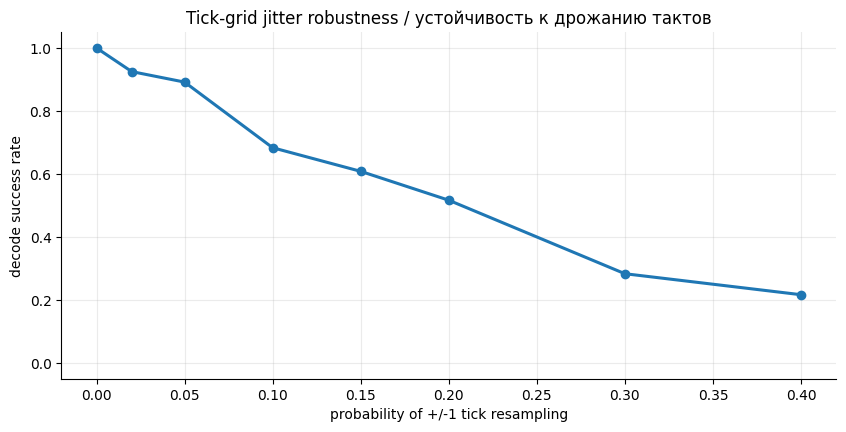

In [7]:
jitter_levels = [0.00, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
jitter_df = pd.DataFrame(monte_carlo_rows(
    model,
    value,
    digit_count,
    clean_total,
    "one-tick jitter probability",
    jitter_levels,
    lambda signal, level, rng: jitter_signal(signal, level, rng),
))

display(jitter_df)
plot_success_curve(jitter_df, "Tick-grid jitter robustness / устойчивость к дрожанию тактов", "probability of +/-1 tick resampling")
plt.show()

## 6. Observation Length / Длина окна наблюдения

**RU.** Даже без шума decoder не может восстановить cell, если окно слишком короткое и не содержит характерного активного фрагмента. Поэтому протоколу нужен минимальный payload window. В packet codec для надежной демонстрации используется эвристика:

$$
T_{payload} = \max_i(S_i + 3P_i) + 1
$$

Она дает каждому selected generator несколько периодов наблюдения. Ниже проверяем, на какой длине текущий decoder начинает стабильно восстанавливать число.

**EN.** Even without noise, the decoder cannot recover a cell if the observation window is too short and does not contain a characteristic active fragment. Therefore the protocol needs a minimum payload window. For reliable demonstration, the packet codec uses this heuristic:

$$
T_{payload} = \max_i(S_i + 3P_i) + 1
$$

It gives each selected generator several periods of observation. Below we check at which length the current decoder starts recovering the number consistently.

,metric,value
0,required_payload_ticks heuristic,30
1,minimum observed_ticks with correct decode in sweep,21
2,margin ticks,9


,observed_ticks,decode_ok,decoded_value,decoded_digits_or_error
0,6,False,NaN,no active segment for digit channel 1
1,7,False,68.0,"(8, 3)"
2,8,False,112.0,"(12, 5)"
3,9,False,112.0,"(12, 5)"
4,10,False,112.0,"(12, 5)"
5,11,False,112.0,"(12, 5)"
6,12,False,477.0,"(17, 23)"
7,13,False,658.0,"(18, 32)"
8,14,False,678.0,"(18, 33)"
9,15,False,678.0,"(18, 33)"


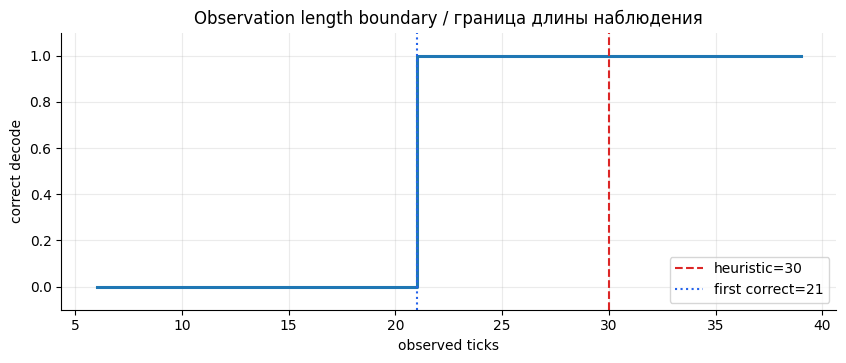

In [8]:
length_rows = []
for observed_ticks in range(6, payload_ticks + 10):
    observed = total_signal(model, value, digit_count, observed_ticks)
    ok = decode_ok(model, observed, value, digit_count)
    decoded_digits = None
    decoded_value = None
    try:
        result = model.decode_step_signal(observed, digit_count=digit_count)
        decoded_digits = result.digits
        decoded_value = result.number
    except ValueError as error:
        decoded_digits = str(error)
    length_rows.append({
        "observed_ticks": observed_ticks,
        "decode_ok": ok,
        "decoded_value": decoded_value,
        "decoded_digits_or_error": decoded_digits,
    })

length_df = pd.DataFrame(length_rows)
minimum_ok_ticks = int(length_df.loc[length_df["decode_ok"], "observed_ticks"].min())
length_summary_df = pd.DataFrame([
    {"metric": "required_payload_ticks heuristic", "value": payload_ticks},
    {"metric": "minimum observed_ticks with correct decode in sweep", "value": minimum_ok_ticks},
    {"metric": "margin ticks", "value": payload_ticks - minimum_ok_ticks},
])

display(length_summary_df)
display(length_df.head(18))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.step(length_df["observed_ticks"], length_df["decode_ok"].astype(int), where="post", linewidth=2.2)
ax.axvline(payload_ticks, color="#DC2626", linestyle="--", label=f"heuristic={payload_ticks}")
ax.axvline(minimum_ok_ticks, color="#2563EB", linestyle=":", label=f"first correct={minimum_ok_ticks}")
ax.set_title("Observation length boundary / граница длины наблюдения")
ax.set_xlabel("observed ticks")
ax.set_ylabel("correct decode")
ax.set_ylim(-0.1, 1.1)
ax.legend(loc="lower right")
plt.show()

## 7. Summary Of Robustness Factors / Сводка факторов устойчивости

**RU.** Сведем результаты в одну таблицу. Здесь важно смотреть не только на “прошло/не прошло”, но и на механизм отказа. Фрактальное число устойчиво к части пропусков, потому что периодическая структура повторяется. Но оно чувствительно к систематической ошибке tick grid, потому что `S_i` и `P_i` являются временными параметрами.

**EN.** We summarize results in one table. It is important to look not only at success/failure, but also at the failure mechanism. A fractal number tolerates some missing samples because the periodic structure repeats. But it is sensitive to systematic tick-grid error because `S_i` and `P_i` are temporal parameters.

In [9]:
def highest_level_at_or_above(df: pd.DataFrame, threshold: float) -> object:
    ok_levels = df.loc[df["success_rate"] >= threshold, "level"]
    return None if ok_levels.empty else ok_levels.max()

robustness_summary_df = pd.DataFrame([
    {
        "factor": "amplitude noise",
        "metric": "Gaussian sigma with success_rate >= 0.95",
        "boundary": highest_level_at_or_above(noise_df, 0.95),
        "engineering meaning": "amplitude noise and drift must stay well below the 0.5 threshold margin",
    },
    {
        "factor": "random sample loss",
        "metric": "drop probability with success_rate >= 0.95",
        "boundary": highest_level_at_or_above(dropout_df, 0.95),
        "engineering meaning": "isolated missing ticks are acceptable while enough active evidence remains",
    },
    {
        "factor": "burst loss",
        "metric": "burst length with success_rate >= 0.95",
        "boundary": highest_level_at_or_above(burst_df, 0.95),
        "engineering meaning": "continuous blind intervals must be shorter than informative active windows or protected by repetition/FEC",
    },
    {
        "factor": "tick-grid jitter",
        "metric": "jitter probability with success_rate >= 0.95",
        "boundary": highest_level_at_or_above(jitter_df, 0.95),
        "engineering meaning": "clock recovery must keep samples aligned to the encoder tick grid",
    },
    {
        "factor": "observation length",
        "metric": "minimum correct ticks in clean sweep",
        "boundary": minimum_ok_ticks,
        "engineering meaning": "payload window must cover enough periods of the slowest selected generator",
    },
])

robustness_summary_df

,factor,metric,boundary,engineering meaning
0,amplitude noise,Gaussian sigma with success_rate >= 0.95,0.20,amplitude noise and drift must stay well below the 0.5 threshold margin
1,random sample loss,drop probability with success_rate >= 0.95,0.05,isolated missing ticks are acceptable while enough active evidence remains
2,burst loss,burst length with success_rate >= 0.95,1.00,continuous blind intervals must be shorter than informative active windows or protected by repetition/FEC
3,tick-grid jitter,jitter probability with success_rate >= 0.95,0.00,clock recovery must keep samples aligned to the encoder tick grid
4,observation length,minimum correct ticks in clean sweep,21.00,payload window must cover enough periods of the slowest selected generator


**Table Fields / Поля таблицы**

**RU.** `factor` - тип искажения или системного ограничения. `metric` - критерий, по которому оценивалась граница. `boundary` - максимальный уровень фактора, при котором success rate в sweep оставался не ниже выбранного порога, или минимальная длина для clean decode. `engineering meaning` - практическое требование к каналу, clock recovery или packet protocol.

**EN.** `factor` is the distortion type or system constraint. `metric` is the boundary criterion. `boundary` is the maximum factor level where sweep success rate stayed above the selected threshold, or the minimum length for clean decoding. `engineering meaning` is the practical requirement for channel, clock recovery, or packet protocol.

## 8. Conclusions / Выводы

**RU.** Этот experiment показывает, что устойчивость фрактального числа определяется не одним параметром. Есть несколько разных границ:

- **Амплитудная граница.** При единичной амплитуде и threshold `0.5` система должна удерживать noise, drift и quantization error внутри этого запаса. Для hardware это означает требования к стабильности уровней, ADC/DAC precision и calibration.
- **Тактовая граница.** `P_i` и `S_i` являются временными параметрами, поэтому decoder чувствителен к рассинхронизации ticks. Clock recovery должен быть частью протокола, а preamble/guard fields должны помогать удерживать phase alignment.
- **Граница потери данных.** Случайные пропуски могут быть допустимы, если остаются активные участки каждого канала. Burst loss опаснее, потому что может удалить целый информативный фрагмент. Для реального канала нужны redundancy, repetition, interleaving или error correction.
- **Граница длины payload.** Нельзя передавать слишком короткий сигнал. Receiver должен увидеть несколько периодов самых медленных selected generators. Эвристика `max(S_i + 3P_i) + 1` дает запас для демонстрационного decoder.
- **Граница текущего prototype.** Эксперимент использует текущий residual-peeling decoder. Для строгого физического протокола потребуется более формальная scoring-модель, учет false positives, оценка confidence и checksum/FEC поверх recovered digits.

Итоговое системное требование: эффективная передача фрактальных чисел требует не только компактного алфавита, но и качественной синхронизации, устойчивого различения амплитудных уровней, достаточного окна наблюдения и протокола восстановления при потерях.

**EN.** This experiment shows that fractal-number robustness is not controlled by one parameter. There are several different boundaries:

- **Amplitude boundary.** With unit amplitude and threshold `0.5`, the system must keep noise, drift, and quantization error inside that margin. For hardware this means requirements on level stability, ADC/DAC precision, and calibration.
- **Clock boundary.** `P_i` and `S_i` are temporal parameters, so the decoder is sensitive to tick misalignment. Clock recovery must be part of the protocol, and preamble/guard fields should help maintain phase alignment.
- **Data-loss boundary.** Random missing samples may be tolerated while active sections of each channel remain observable. Burst loss is more dangerous because it may remove an entire informative fragment. A real channel needs redundancy, repetition, interleaving, or error correction.
- **Payload-length boundary.** The signal cannot be too short. The receiver must observe several periods of the slowest selected generators. The heuristic `max(S_i + 3P_i) + 1` provides margin for the demonstration decoder.
- **Prototype boundary.** The experiment uses the current residual-peeling decoder. A strict physical protocol needs a more formal scoring model, false-positive accounting, confidence estimation, and checksum/FEC over recovered digits.

Final system requirement: efficient fractal-number transmission requires not only a compact alphabet, but also high-quality synchronization, stable amplitude-level discrimination, sufficient observation window, and a recovery protocol for missing data.